In [1]:
import torch 
import torch.nn as nn
import numpy as np
#turn off scientific notation
torch.set_printoptions(sci_mode=False)

import copy
import torch.nn.functional as F

import tqdm
# from torch_linear_assignment import batch_linear_assignment, assignment_to_indices
from typing import List, Tuple, Dict, Any, Literal, Optional, Union

from src.utils.normalizer import Normalizer
from src.quantize_compress import LinearVQ
from src.utils import utils
from src.huffman import HuffmanUser
import yaml
from collections import Counter
import matplotlib.pyplot as plt
import random
from itertools import product


In [2]:
# set CUDA_LAUNCH_BLOCKING=1
# to get the correct error message

! export CUDA_LAUNCH_BLOCKING=1

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# load config from yaml
with open("config/compress/vq.yaml", "r") as f:
    vq_config = yaml.safe_load(f)

weight_path = "./models/meta-llama/Meta-Llama-3-8B/original_weights/layer_0/self_attn.q_proj.pt"
hessian_diag = weight_path.replace("original_weights", "hessianDiags/seed_0/pajama/128")


weight = torch.load(weight_path, map_location=device)["weight"].to(torch.float32).detach()
hessian_diag = torch.load(hessian_diag, map_location=device)["hessianDiag"].to(torch.float32)

hessian_diag = hessian_diag/torch.median(hessian_diag)

normalizer, normalized_weight = Normalizer.normalize_init(weight, norm_order=[0,1], zero = [False, False])


compression_module = LinearVQ(weight=weight)
compression_module.hessianDiag = hessian_diag
compression_module.compress(**vq_config['kwargs'])
compression_measure = (
                    compression_module.get_n_bits(),
                    compression_module.get_n_original_parameters(),
                )
print('weight shape', weight.shape)
print('bits and num params', compression_measure)
print('assignments shape', compression_module.assignments.shape)

compression_severity = 1.5
compression_str = f'{vq_config['kwargs']['n_bits']}_bits_to_{vq_config['kwargs']['n_bits']-compression_severity}_bits'








weight shape torch.Size([4096, 4096])
bits and num params (67109120.0, 16777216)
assignments shape torch.Size([16777216])


In [4]:
bin_size = 256
bin_bit_limit = bin_size * (vq_config['kwargs']['n_bits'] - compression_severity)
huffman_args = {
    'bin_size': bin_size,
    'bin_bit_limit': bin_bit_limit,
    'heuristic_metric': "output_normed_sum",
    'heuristic_algo': "min_max",
    'lsa_metric': "bit_violation",
    'lsa_prep': 'none',
    'heuristic': True,
    'lsa': True
}
print(huffman_args)
huffman_description = compression_str
for key, value in huffman_args.items():
    huffman_description += f'__{key}_{value}'
print(huffman_description)

{'bin_size': 256, 'bin_bit_limit': 640.0, 'heuristic_metric': 'output_normed_sum', 'heuristic_algo': 'min_max', 'lsa_metric': 'bit_violation', 'lsa_prep': 'none', 'heuristic': True, 'lsa': True}
4_bits_to_2.5_bits__bin_size_256__bin_bit_limit_640.0__heuristic_metric_output_normed_sum__heuristic_algo_min_max__lsa_metric_bit_violation__lsa_prep_none__heuristic_True__lsa_True


In [5]:
huffman_module = HuffmanUser("HuffmanStrategy")
res = huffman_module.encode(compression_module.assignments.cpu().numpy().reshape(weight.shape))
bit_count_matrix = res['bit_count_matrix']
print(res['stats'])

code    symbol
00 0
010 14
0110 5
01110 8
0111100 1
011110100 11
011110101000000 6
011110101000001 4
01111010100001 7
0111101010001 10
011110101001 13
01111010101 15
0111101011 2
01111011 9
011111 12
1 3
{'frequencies': {0: np.int64(3139113), 1: np.int64(161912), 2: np.int64(24737), 3: np.int64(9663864), 4: np.int64(189), 5: np.int64(1088908), 6: np.int64(99), 7: np.int64(799), 8: np.int64(550807), 9: np.int64(97963), 10: np.int64(1468), 11: np.int64(40498), 12: np.int64(362749), 13: np.int64(5311), 14: np.int64(1630279), 15: np.int64(8520)}, 'compression_ratio': np.float64(32.69608816302767), 'original_size_bits': 1073741824, 'encoded_size_bits': 32840070, 'execution_time': 3.484365701675415}


In [6]:
temp = np.arange(10)
print(temp[9:0:-1])

[9 8 7 6 5 4 3 2 1]


In [7]:

print("bin_bit_limit", bin_bit_limit)

# permuted_bit_count_matrix = huffman_module.column_permute(bit_count_matrix,\
#                                                           bin_size=bin_size,\
#                                                           bin_bit_limit=bin_bit_limit,\
#                                                           heuristic_metric="output_normed_sum",\
#                                                           heuristic_algo="min_max",\
#                                                           lsa_metric="num_violation",\
#                                                           heuristic=True,\
#                                                           lsa=True)
permuted_bit_count_matrix = huffman_module.column_permute(bit_count_matrix, **huffman_args)
# print('permuted bit count matrix.shape', permuted_bit_count_matrix.shape)

# violations = huffman_module.count_violations(permuted_bit_count_matrix, bin_size=bin_size, bin_bit_limit=bin_bit_limit)

# print(np.sum(violations))
# print('violations shape', violations.shape)

# print("violations by bits\n",violations) 

# print("bin violations percentage", np.sum(violations>0)/(np.prod(violations.shape)))
# print('average huffman length', np.mean(bit_count_matrix))

# assert np.sum(bit_count_matrix) == np.sum(permuted_bit_count_matrix)
 

bin_bit_limit 640.0
bit_count_matrix shape (4096, 4096)
bit_count_matrix shape after padding (4096, 4096)


100%|██████████| 256/256 [12:21<00:00,  2.90s/it]


In [8]:
import os
output_matrix_dir = 'permuted_bit_count_matrices'
os.makedirs(output_matrix_dir, exist_ok=True)
np.save(os.path.join(output_matrix_dir, f'permuted_bit_count_matrix_{huffman_description}.npy'),permuted_bit_count_matrix)

In [9]:
violations = huffman_module.count_violations(permuted_bit_count_matrix, bin_size=bin_size, bin_bit_limit=bin_bit_limit)
print(huffman_description)
print('permuted bit count matrix.shape', permuted_bit_count_matrix.shape)
print('total bits subtracted by bin limit', np.sum(violations))
print('total bits over', np.sum(violations * (violations>0)))
only_pos_violations = violations * (violations>0).astype(int)
print(np.min(only_pos_violations))
print(np.max(only_pos_violations))


print('violations shape', violations.shape)

print("violations by bits\n",violations) 
print("violations max", np.max(violations))

print("bin violations percentage", np.sum(violations>0)/(np.prod(violations.shape)))
print('average huffman length', np.mean(bit_count_matrix))

assert np.sum(bit_count_matrix) == np.sum(permuted_bit_count_matrix)
 

4_bits_to_2.5_bits__bin_size_256__bin_bit_limit_640.0__heuristic_metric_output_normed_sum__heuristic_algo_min_max__lsa_metric_bit_violation__lsa_prep_none__heuristic_True__lsa_True
permuted bit count matrix.shape (4096, 4096)
total bits subtracted by bin limit -9102970.0
total bits over 433300.0
-0.0
388.0
violations shape (4096, 16)
violations by bits
 [[-168. -166. -177. ... -182. -147. -131.]
 [ -54.  -66.  -63. ...  -66.  -22.  -51.]
 [ -74. -112. -137. ... -140. -104.  -94.]
 ...
 [-169. -164. -132. ... -160. -132. -148.]
 [-248. -234. -226. ... -220. -221. -236.]
 [-246. -241. -229. ... -243. -246. -233.]]
violations max 388.0
bin violations percentage 0.090423583984375
average huffman length 1.9574207067489624


(4096, 16)
(4096, 4096)


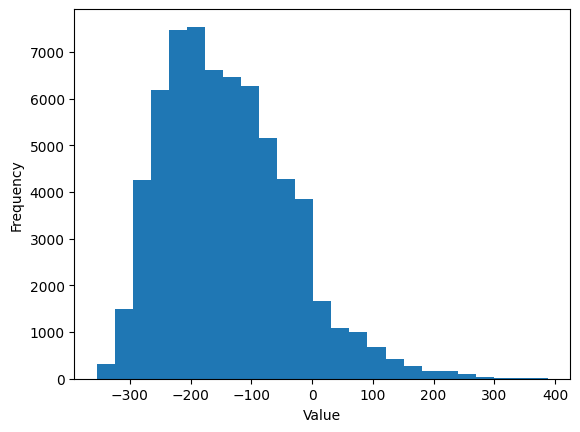

In [10]:
print(violations.shape)
print(permuted_bit_count_matrix.shape)
plt.hist(violations.flatten(), bins=25)
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.show()

In [11]:
violations[0][:100]

array([-168., -166., -177., -159., -146., -163., -153., -152., -162.,
       -163., -171., -148., -144., -182., -147., -131.])

In [12]:
violations[0][-100:]

array([-168., -166., -177., -159., -146., -163., -153., -152., -162.,
       -163., -171., -148., -144., -182., -147., -131.])

bit count matrix Counter({np.int32(1): 9663864, np.int32(2): 3139113, np.int32(3): 1630279, np.int32(4): 1088908, np.int32(5): 550807, np.int32(6): 362749, np.int32(7): 161912, np.int32(8): 97963, np.int32(9): 40498, np.int32(10): 24737, np.int32(11): 8520, np.int32(12): 5311, np.int32(13): 1468, np.int32(14): 799, np.int32(15): 288})


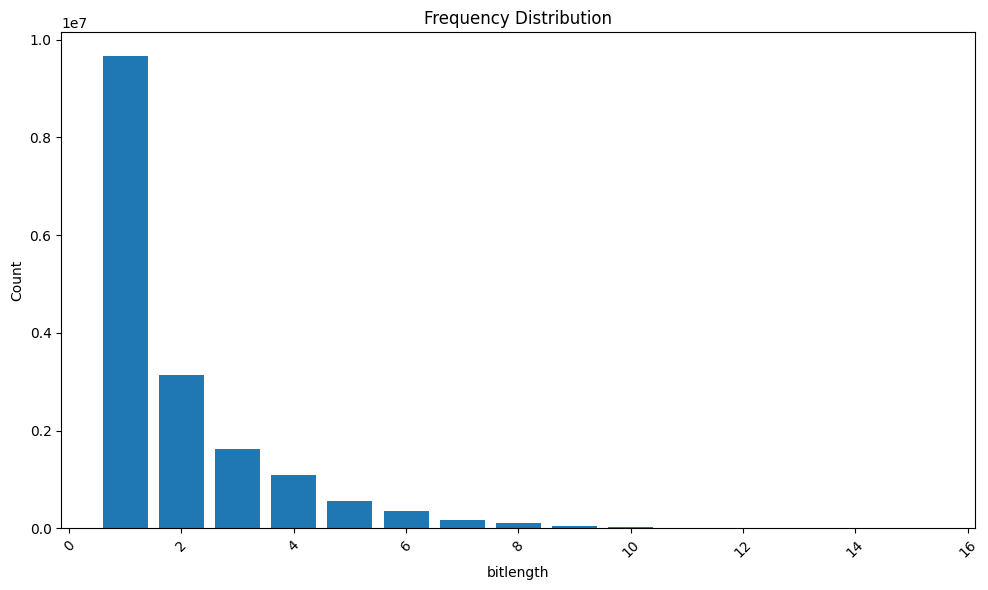

In [13]:
# print(Counter(bit_count_matrix.flatten()))
counter = Counter(bit_count_matrix.flatten())
print("bit count matrix", counter)

plt.figure(figsize=(10, 6))
plt.bar(counter.keys(), counter.values())
plt.title('Frequency Distribution')
plt.xlabel('bitlength')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [14]:
def get_entropy(matrix):
    unique_vals, counts = np.unique(matrix, return_counts=True)
    probabilities = counts / np.prod(matrix.shape)
    
    # Calculate entropy: H = -Σ p(x) * log2(p(x))
    entropy = -np.sum(probabilities * np.log2(probabilities + 1e-12))  # Add epsilon for numerical stability
    return entropy

In [15]:
print(np.unique(compression_module.assignments.cpu().numpy()))

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15]


In [16]:
print("entropy", get_entropy(compression_module.assignments.cpu().numpy()))

entropy 1.929341462402626


In [17]:
# TODO: THIS UNDOS EVERYTHING, DON'T UNCOMMENT
# # loop through the different permutation methods

# # for heuristic_algo in ["round_robin", "min_max"]:
# #     for heuristic_metric in ['sum', 'output_normed_sum']:
# x_powers = np.arange(12) + 1 #min_max doesn't work for bin size of 1
# x_values = 2**x_powers
# print('xval', x_values)
# heuristic_algos = ["round_robin", "min_max"]
# heuristic_metrics = ['sum', 'output_normed_sum']

# param_combinations = list(product(heuristic_algos, heuristic_metrics))

# plt.figure(figsize=(10,10))

# # Plot a line for each parameter combination
# for param1, param2 in param_combinations:
#     # Calculate y values using the mystery function
#     y_values = []
#     for x in x_values:
#         bin_size = x
#         bin_bit_limit = bin_size * (vq_config['kwargs']['n_bits'] - 1)
#         permuted_bit_count_matrix = huffman_module.column_permute(bit_count_matrix, \
#                                                                   bin_size=bin_size, \
#                                                                   bin_bit_limit=bin_bit_limit, \
#                                                                   heuristic_metric=param2, \
#                                                                   heuristic_algo=param1, \
#                                                                   lsa_metric="bit_violation", \
#                                                                   heuristic=True, lsa=False)
#         # print(permuted_bit_count_matrix.shape)
#         violations = huffman_module.count_violations(permuted_bit_count_matrix, bin_size=bin_size, bin_bit_limit=bin_bit_limit)
#         y_values.append(np.sum(violations>0)/(np.prod(violations.shape)))
    
#     # Create label for the line
#     label = f'{param1}_{param2}'
    
#     # Plot the line
#     plt.plot(x_values, y_values, marker='o', label=label, linewidth=2, markersize=4)

# y_values = []
# for x in x_values:
#     bin_size = x
#     bin_bit_limit = bin_size * (vq_config['kwargs']['n_bits'] - 1)
#     permuted_bit_count_matrix = huffman_module.column_permute(bit_count_matrix, \
#                                                                   bin_size=bin_size, \
#                                                                   bin_bit_limit=bin_bit_limit, \
#                                                                   heuristic_metric=param2, \
#                                                                   heuristic_algo=param1, \
#                                                                   lsa_metric="bit_violation", \
#                                                                   heuristic=False, lsa=False)
#     # print(permuted_bit_count_matrix.shape)
#     violations = huffman_module.count_violations(permuted_bit_count_matrix, bin_size=bin_size, bin_bit_limit=bin_bit_limit)
#     y_values.append(np.sum(violations>0)/(np.prod(violations.shape)))

# # Create label for the line
# label = f'no_heuristic'

# # Plot the line
# plt.plot(x_values, y_values, marker='o', label=label, linewidth=2, markersize=4)

# # Set log scale for x-axis
# plt.xscale('log', base=2)

# # Customize the plot
# plt.xlabel('X (Powers of 2)', fontsize=12)
# plt.ylabel('violations', fontsize=12)
# plt.title('4 bit -> 3 bit', fontsize=14)
# plt.grid(True, alpha=0.3)
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')


# # Set x-axis ticks to show powers of 2
# plt.xticks(x_values, [f'2^{i}' for i in x_powers], rotation=45)

# # Adjust layout to prevent legend cutoff
# plt.tight_layout()

# # Show the plot
# plt.show()

    